# 03 · Precio esperado y brecha de precio

**Propósito.** Estimar, para cada aviso, cuánto debería pedirse por m² según lo que tiene el departamento y
dónde está (**precio esperado**), y medir cuánto se aleja el precio publicado de ese valor (**brecha de precio**).
Con eso se evalúa H1 y se arma el **ranking de avisos a investigar**.

| | Hipótesis | Dónde se evalúa |
|---|---|---|
| H1 | Dentro de una zona hay avisos publicados claramente por debajo del precio esperado para sus características, más allá del margen normal de negociación (~5%). | Secciones 6 a 9 |

**Cómo leer la brecha.** −0,25 significa que el aviso pide 25% menos que el precio esperado. Una brecha muy negativa
es una **señal de precio atípicamente bajo para investigar**, no una subvaluación confirmada: puede ser un error
de carga, un defecto que el aviso no informa o un vendedor apurado.

## 1. Configuración e ingesta

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import modelo
from src.eda import AZUL, AZUL_OSCURO, GRIS, ROJO

In [3]:
PARAMS = {
    "entrada": RAIZ / "data" / "processed" / "propiedades_limpias.tsv",
    "salida_precio_esperado": RAIZ / "data" / "processed" / "precio_esperado.tsv",
    "salida_ranking": RAIZ / "data" / "processed" / "avisos_a_investigar.csv",
    "k_folds": 5,           # partes de la validación cruzada
    "minimo_grupo": 10,     # avisos mínimos para usar una zona como referencia
    "semilla": 42,
    "brecha_negociacion": -0.05,   # brecha publicado vs. cierre (contexto argentino, punto 5)
    "umbral": -0.25,               # desde acá un aviso queda marcado (ver sección 6)
}

In [4]:
df = pd.read_csv(PARAMS["entrada"], sep="\t", low_memory=False)
y = np.log(df["precio_m2_usd"])
print(f"Avisos: {len(df):,}")

Avisos: 27,579


## 2. Zona de referencia

**Pregunta:** ¿contra qué zona se compara cada aviso?

El notebook 02 mostró que la sub-zona mejora la referencia de precio en algunos barrios y no en otros (H2, apoyo
parcial). La regla que usamos sale de ese resultado: **sub-zona solo en los barrios donde baja el error fuera de
muestra; barrio en el resto**. Los avisos sin coordenadas y las zonas con menos de 10 avisos usan el barrio.

In [5]:
tabla_zonas = modelo.barrios_donde_conviene_subzona(df, PARAMS["k_folds"], PARAMS["minimo_grupo"], PARAMS["semilla"])
barrios_subzona = tabla_zonas.index[tabla_zonas["conviene_subzona"]]
df["zona"] = modelo.zona_de_referencia(df, barrios_subzona, PARAMS["minimo_grupo"])

usa_subzona = df["zona"] != df["barrio"]
print(f"Barrios donde conviene la sub-zona: {len(barrios_subzona)} de {len(tabla_zonas)}")
print(f"Zonas de referencia: {df['zona'].nunique()}")
print(f"Avisos comparados contra su sub-zona: {usa_subzona.sum():,} ({100 * usa_subzona.mean():.1f}%)")

Barrios donde conviene la sub-zona: 28 de 47
Zonas de referencia: 166
Avisos comparados contra su sub-zona: 15,946 (57.8%)


## 3. Características del modelo

El modelo explica el logaritmo del precio por m² con las características de la tabla y una constante por zona.
Al usar logaritmo, cada coeficiente se lee como una diferencia porcentual de precio.

| Grupo | Variables | Por qué |
|---|---|---|
| Tamaño | log de la superficie, ambientes, baños | Los departamentos más grandes suelen tener menor precio por m² |
| Antigüedad | 5 tramos + "sin dato" (base: más de 70 años) | Fue la variable con más peso en el EDA (+22% a −18%) |
| Edificio | cochera, ascensor, pileta, gimnasio, SUM, seguridad, parrilla | Amenities: +17,5% aun comparando a igual antigüedad |
| Unidad | piso, contrafrente, balcón, terraza, suite, aire acondicionado, apto profesional | Diferencias dentro del mismo edificio |
| Financiamiento | apto crédito | Control: se asocia a precios 4% menores dentro de la sub-zona (contexto, punto 3) |
| Ubicación | zona de referencia (sección 2) | Absorbe el nivel de precio de cada zona |

**Variables excluidas por usar el precio** (filtración: el modelo "vería" la respuesta): `bajo_de_precio`,
`precio_anterior_usd`, `baja_pct`, `outlier_precio_m2`. Tampoco se usan las expensas: faltan en 16% de los avisos y
en buena parte reflejan las amenities, que ya están en el modelo.

**Distancia al subte y centralidad:** no entran. Dentro de la zona no mostraron relación con el precio una vez
controlada la antigüedad (H3, notebook 02).

In [6]:
X = modelo.matriz_caracteristicas(df)
A = modelo.matriz_diseno(X, df["zona"])
print(f"Características: {X.shape[1]} | columnas totales con zonas: {A.shape[1]}")
print(f"Valores faltantes en la matriz: {int(A.isna().sum().sum())}")

Características: 25 | columnas totales con zonas: 191
Valores faltantes en la matriz: 0


## 4. Precio esperado fuera de muestra

**Pregunta:** ¿el modelo da una referencia mejor que la mediana de la zona?

**Cómo se mide.** Validación cruzada en 5 partes: el precio esperado de cada aviso sale de un modelo ajustado con
el resto. Las partes se arman **por unidad** (misma dirección y misma superficie), para que un posible duplicado no
quede de los dos lados y el modelo no "reconozca" el aviso. Se compara contra la referencia más simple: la mediana
del precio por m² de la zona, calculada igual, fuera de muestra.

**Decisión operativa:** el modelo se ajusta sin los outliers de precio por m² (3,4%, casi todos por arriba de su
zona), para que no tiren hacia arriba el precio esperado de los demás. El precio esperado se calcula igual para todos.

In [7]:
folds = modelo.folds_agrupados(modelo.grupo_de_unidad(df), PARAMS["k_folds"], PARAMS["semilla"])
entrena_con = ~df["outlier_precio_m2"]

log_esperado, log_mediana_zona = modelo.precio_esperado_fuera_de_muestra(y, A, df["zona"], folds, entrena_con)
df["precio_m2_esperado"] = np.exp(log_esperado)
df["brecha"] = df["precio_m2_usd"] / df["precio_m2_esperado"] - 1

In [8]:
error_modelo = df["brecha"].abs()
error_zona = (df["precio_m2_usd"] / np.exp(log_mediana_zona) - 1).abs()

comparacion = pd.DataFrame({
    "Mediana de la zona": error_zona.quantile([0.25, 0.5, 0.75]),
    "Modelo de precio esperado": error_modelo.quantile([0.25, 0.5, 0.75]),
}).T.mul(100).round(1)
comparacion.columns = ["p25", "mediana", "p75"]
comparacion

,p25,mediana,p75
Mediana de la zona,8.3,17.2,29.9
Modelo de precio esperado,5.9,12.7,22.3


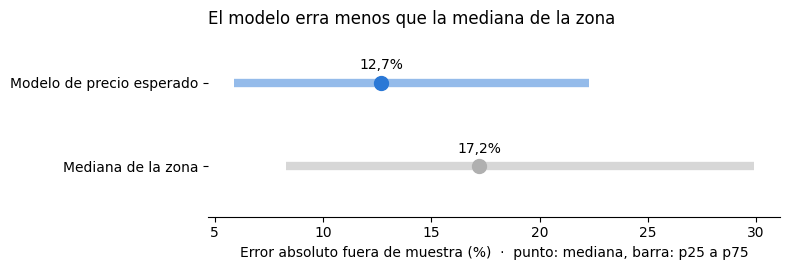

In [9]:
fig, ax = plt.subplots(figsize=(8, 2.8))
filas = ["Mediana de la zona", "Modelo de precio esperado"]
colores = [GRIS, AZUL]
for i, (fila, color) in enumerate(zip(filas, colores)):
    p25, med, p75 = comparacion.loc[fila]
    ax.hlines(i, p25, p75, color=color, lw=6, alpha=0.5)
    ax.plot(med, i, "o", color=color, ms=10)
    ax.annotate(f"{med:.1f}%".replace(".", ","), (med, i), xytext=(0, 10), textcoords="offset points", ha="center")
ax.set_yticks(range(len(filas)), filas)
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("Error absoluto fuera de muestra (%)  ·  punto: mediana, barra: p25 a p75")
ax.set_title("El modelo erra menos que la mediana de la zona", loc="left")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

> **Interpretación:** El modelo da una referencia de precio más precisa que la mediana de la zona: el error mediano baja de 17,2% a 12,7% (4,5 puntos, un cuarto menos), y la mejora no se limita al aviso típico, porque el percentil 75 del error baja de 29,9% a 22,3%. En la práctica, para un aviso cualquiera el precio esperado queda, en la mediana, a un 13% del publicado, en más o en menos: alcanza para ordenar avisos y detectar los que se alejan mucho, pero no para tasar un departamento en particular. Por eso el umbral para marcar un precio como atípicamente bajo tiene que ser bastante mayor que ese error.

## 5. Prima por característica

**Pregunta:** ¿qué características pesan más en el precio por m², comparando dentro de la misma zona?

Se ajusta el modelo con todos los avisos (sin outliers) y se lee cada coeficiente como diferencia porcentual. Son
**asociaciones**, no efectos causales: un coeficiente puede recoger otras diferencias que no observamos.

In [10]:
coef = modelo.ajustar(y, A, entrena_con)
prima = modelo.prima_porcentual(coef[X.columns]).sort_values()
prima.round(1).to_frame("prima_%")

,prima_%
log_m2,-17.7
apto_profesional,-3.3
apto_credito,-1.2
contrafrente,-0.6
ascensor,-0.1
piso,0.7
seguridad,0.9
antiguedad_51_70,1.8
terraza,1.9
aire_acondicionado,2.1


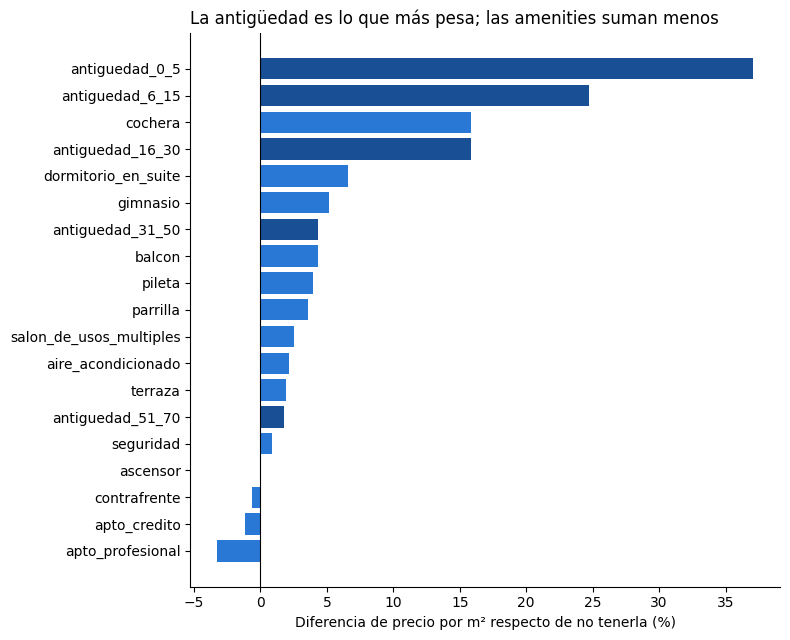

In [11]:
mostrar = prima.drop(["log_m2", "piso", "ambientes", "banos", "antiguedad_sin_dato", "piso_sin_dato"]) 
fig, ax = plt.subplots(figsize=(8, 6.5))
color = [AZUL_OSCURO if n.startswith("antiguedad") else AZUL for n in mostrar.index]
ax.barh(mostrar.index, mostrar.values, color=color)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Diferencia de precio por m² respecto de no tenerla (%)")
ax.set_title("La antigüedad es lo que más pesa; las amenities suman menos", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
print(f"Superficie: +10% de m² se asocia a {modelo.prima_porcentual(coef['log_m2'] * np.log(1.1)):.1f}% de precio por m²")
for c in ["ambientes", "banos", "piso"]:
    print(f"{c}: {prima[c]:+.1f}% por unidad adicional")

Superficie: +10% de m² se asocia a -1.8% de precio por m²
ambientes: +2.5% por unidad adicional
banos: +4.5% por unidad adicional
piso: +0.7% por unidad adicional


> **Interpretación:** Comparando dentro de la misma zona, la antigüedad es lo que más pesa: un edificio de 0 a 5 años se publica 37% más caro por m² que uno de más de 70, y la prima cae a medida que el edificio envejece. Le sigue la cochera (+16%). Las amenities suman de a poco (suite, gimnasio, pileta, parrilla, entre 3% y 7% cada una), lo que coincide con el EDA: el 17,5% de tener amenities se reparte entre varias y parte lo explica la cochera. Apto profesional y apto crédito se asocian a precios algo menores, en línea con lo que vimos en el contexto. Las categorías "sin dato" de antigüedad y piso no son características: están en el modelo para no perder esos avisos y no se interpretan. Son asociaciones, no efectos causales.

## 6. Brecha de precio y umbral

**Pregunta:** ¿desde qué brecha un precio es atípicamente bajo?

El umbral tiene que superar dos cosas que hacen que un aviso parezca barato sin serlo:

- **El error típico del modelo** (sección 4, ~13%): una brecha de ese tamaño es lo normal para cualquier aviso.
- **La brecha de negociación** (~5%, contexto argentino punto 5): parte de lo publicado no se convalida.

Elegimos **−25%**: es dos veces el error mediano del modelo (12,7%) y supera con margen la suma de error y negociación
(cerca de −18%).

**Límite de esta marca.** La brecha de un aviso es justamente el error del modelo para ese aviso, así que con estos
datos no se puede separar, para un aviso dado, un precio atípico de un error de estimación. La celda que sigue a la
distribución compara cuántos avisos se marcarían si toda la brecha fuera error del modelo.

In [13]:
cortes = [-0.05, -0.15, -0.20, -0.25, -0.30]
sensibilidad = pd.DataFrame({
    "avisos": [(df["brecha"] < c).sum() for c in cortes],
    "%_del_total": [100 * (df["brecha"] < c).mean() for c in cortes],
}, index=[f"{100 * c:.0f}%" for c in cortes]).round(1)
sensibilidad.index.name = "brecha menor a"
sensibilidad

,avisos,%_del_total
brecha menor a,,
-5%,10355,37.5
-15%,5009,18.2
-20%,3012,10.9
-25%,1704,6.2
-30%,896,3.2


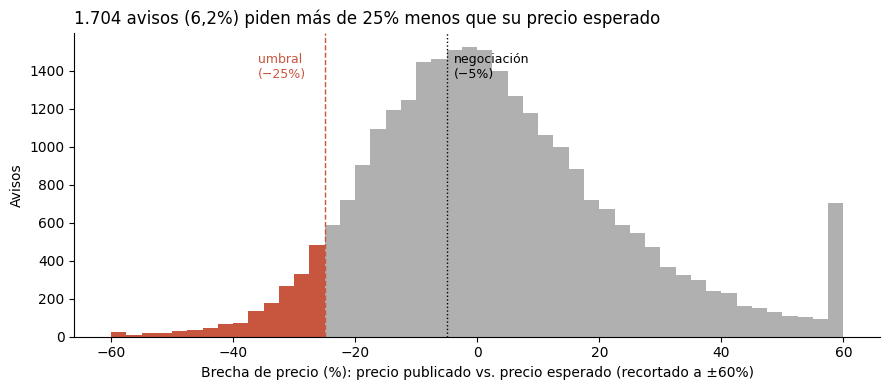

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
valores = 100 * df["brecha"].clip(-0.6, 0.6)
ax.hist(valores, bins=np.arange(-60, 61, 2.5), color=GRIS)
ax.hist(valores[df["brecha"] < PARAMS["umbral"]], bins=np.arange(-60, 61, 2.5), color=ROJO)
ax.axvline(100 * PARAMS["brecha_negociacion"], color="black", ls=":", lw=1)
ax.axvline(100 * PARAMS["umbral"], color=ROJO, ls="--", lw=1)
ax.annotate("negociación\n(−5%)", (100 * PARAMS["brecha_negociacion"], ax.get_ylim()[1] * 0.85), xytext=(5, 0),
            textcoords="offset points", fontsize=9)
ax.annotate("umbral\n(−25%)", (100 * PARAMS["umbral"], ax.get_ylim()[1] * 0.85), xytext=(-48, 0),
            textcoords="offset points", fontsize=9, color=ROJO)
ax.set_xlabel("Brecha de precio (%): precio publicado vs. precio esperado (recortado a ±60%)")
ax.set_ylabel("Avisos")
n = (df["brecha"] < PARAMS["umbral"]).sum()
ax.set_title(f"{n:,} avisos ({100 * n / len(df):.1f}%) piden más de 25% menos que su precio esperado".replace(",", "X").replace(".", ",").replace("X", "."), loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
# ¿Cuántos avisos se marcarían si toda la brecha fuera error del modelo?
# Se ajusta una normal a log(1 + brecha) con un desvío robusto (MAD) y se mira su cola por debajo del umbral
log_brecha = np.log1p(df["brecha"])
desvio_robusto = 1.4826 * np.median(np.abs(log_brecha - log_brecha.median()))
esperado_ruido = stats.norm.cdf((np.log1p(PARAMS["umbral"]) - log_brecha.median()) / desvio_robusto)
print(f"Marcados observados: {100 * (df['brecha'] < PARAMS['umbral']).mean():.1f}% | "
      f"esperados solo por el error del modelo: {100 * esperado_ruido:.1f}%")

Marcados observados: 6.2% | esperados solo por el error del modelo: 6.0%


> **Interpretación:** Con un umbral de −25% quedan marcados 1.704 avisos (6,2%). La distribución de la brecha está centrada cerca de 0 y es asimétrica: la cola de abajo es más corta que la de arriba, donde se acumulan avisos muy por encima de su precio esperado. El umbral queda en la cola de abajo, en dos veces el error típico del modelo, y por encima de la suma de ese error (~13%) y la brecha de negociación (~5%). Pero la proporción de marcados (6,2%) es casi la que produciría el error del modelo por sí solo (6,0% si fuera normal): la marca no prueba que haya precios atípicos más allá del error, sino que ordena los avisos según cuánto se alejan de lo esperado. La tabla de sensibilidad muestra que el resultado depende del corte: con −20% serían 3.012 avisos y con −30%, 896. Elegimos −25% como punto intermedio con margen sobre el error, y en la sección 7 se revisa qué parte de los marcados puede ser un error de carga.

## 7. ¿Son errores de carga?

**Pregunta:** ¿cuántos avisos marcados tienen alguna señal de que el dato puede estar mal?

Antes de leer una brecha grande como oportunidad, hay que descartar que el aviso esté mal cargado. Se usan las
marcas del notebook 01 y una señal nueva: una superficie que no cuadra con los ambientes (por ejemplo, 706 m² en
3 ambientes). Son señales para revisar, no exclusiones. No se usa una señal basada en el precio (por ejemplo, "precio por
m² entre los más bajos de la ciudad"): sería circular, porque los marcados son baratos por definición, y castigaría a
los barrios más baratos del sur.

In [16]:
df["marcado"] = df["brecha"] < PARAMS["umbral"]
m2_por_ambiente = df["m2_final"] / df["ambientes"].fillna(df["dormitorios"] + 1).clip(lower=1)
senales = {
    "m² por ambiente fuera del 1% a 99%": ~m2_por_ambiente.between(*m2_por_ambiente.quantile([0.01, 0.99])),
    "superficie recuperada de la total": df["m2_origen"] == "recuperada_de_total",
    "incoherencia de dormitorios": df["incoherencia_dormitorios"],
    "incoherencia de piso": df["incoherencia_piso"],
    "menciona alquiler en el título": df["menciona_alquiler"],
    "posible duplicado": df["posible_duplicado"],
}
tabla_senales = pd.DataFrame({
    "marcados_%": {k: 100 * v[df["marcado"]].mean() for k, v in senales.items()},
    "resto_%": {k: 100 * v[~df["marcado"]].mean() for k, v in senales.items()},
}).round(1)
tabla_senales

,marcados_%,resto_%
m² por ambiente fuera del 1% a 99%,2.9,1.9
superficie recuperada de la total,0.2,0.1
incoherencia de dormitorios,2.5,1.3
incoherencia de piso,8.9,8.3
menciona alquiler en el título,0.5,0.6
posible duplicado,11.9,11.0


In [17]:
alguna = pd.concat([v for k, v in senales.items() if k != "posible duplicado"], axis=1).any(axis=1)
df["senal_error_carga"] = alguna

print(f"Marcados con alguna señal de error de carga: {alguna[df['marcado']].sum():,} "
      f"({100 * alguna[df['marcado']].mean():.1f}%) | en el resto: {100 * alguna[~df['marcado']].mean():.1f}%")

Marcados con alguna señal de error de carga: 246 (14.4%) | en el resto: 11.8%


> **Interpretación:** Los avisos marcados tienen más señales de error de carga que el resto (14,4% contra 11,8%). Es lo esperable: un precio muy por debajo de lo que corresponde es justamente lo que produce un dato mal cargado, como una superficie inflada o un precio con un dígito de menos. Las señales que más se separan son la superficie que no cuadra con los ambientes (2,9% contra 1,9%), que explica varios de los primeros puestos del ranking, y la incoherencia de dormitorios (2,5% contra 1,3%). La incoherencia de piso aparece casi igual en los dos grupos, así que no tiene relación con el precio. Para la lista, esto implica que una brecha grande no alcanza para hablar de oportunidad: primero hay que descartar el error de carga, y aun los avisos sin señales pueden tener errores que estas reglas no detectan.

## 8. Avisos que bajaron de precio

**Pregunta:** ¿los avisos con "BAJÓ DE PRECIO" están más abajo de su precio esperado?

Se revisan aparte porque una baja puede indicar un vendedor apurado (iliquidez, contexto punto 4) y no una
oportunidad. La variable no entra al modelo (usa el precio), así que se puede comparar sin circularidad.

In [18]:
resumen_baja = df.groupby("bajo_de_precio").agg(
    avisos=("brecha", "size"),
    brecha_mediana_pct=("brecha", lambda s: 100 * s.median()),
    marcados_pct=("marcado", lambda s: 100 * s.mean()),
).round(1)
resumen_baja.index = resumen_baja.index.map({False: "Sin baja", True: "Bajó de precio"})
resumen_baja

,avisos,brecha_mediana_pct,marcados_pct
bajo_de_precio,,,
Sin baja,26953,0.8,6.0
Bajó de precio,626,-6.3,13.3


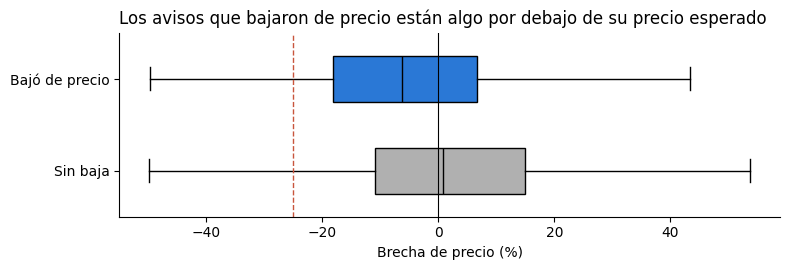

In [19]:
fig, ax = plt.subplots(figsize=(8, 2.8))
grupos = [100 * df.loc[~df["bajo_de_precio"], "brecha"], 100 * df.loc[df["bajo_de_precio"], "brecha"]]
caja = ax.boxplot(grupos, vert=False, widths=0.5, showfliers=False, patch_artist=True,
                  tick_labels=["Sin baja", "Bajó de precio"])
for parche, color in zip(caja["boxes"], [GRIS, AZUL]):
    parche.set_facecolor(color)
for mediana in caja["medians"]:
    mediana.set_color("black")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(100 * PARAMS["umbral"], color=ROJO, ls="--", lw=1)
ax.set_xlabel("Brecha de precio (%)")
ax.set_title("Los avisos que bajaron de precio están algo por debajo de su precio esperado", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

> **Interpretación:** Los avisos que bajaron de precio están por debajo de su precio esperado (brecha mediana de −6,3% contra +0,8% del resto) y aparecen más del doble entre los marcados (13,3% contra 6,0%). Se pueden leer de las dos formas según el caso. En el caso típico, la baja mediana (6,8%) es casi igual a la brecha: antes de bajar estaban cerca de su precio esperado, y la baja los acerca al precio de cierre. Eso se parece más a un vendedor apurado que a una oportunidad. En cambio, en los que quedan por debajo de −25%, la baja no alcanza a explicar la brecha: ya estaban baratos antes. Esos sí merecen revisarse como avisos a investigar, siempre descartando antes un error de carga. Como no hay fechas, no podemos saber cuánto tiempo llevaban publicados.

## 9. Dónde están los avisos marcados

**Pregunta:** ¿los avisos marcados se concentran en algunos barrios?

Si se concentran donde el modelo erra más, parte de la marca puede ser error del modelo y no del precio.

In [20]:
por_barrio = df.groupby("barrio").agg(
    avisos=("marcado", "size"),
    marcados=("marcado", "sum"),
    error_mediano_pct=("brecha", lambda s: 100 * s.abs().median()),
)
por_barrio["marcados_pct"] = 100 * por_barrio["marcados"] / por_barrio["avisos"]
por_barrio = por_barrio[por_barrio["avisos"] >= 100].sort_values("marcados_pct", ascending=False)
por_barrio.head(10).round(1)

,avisos,marcados,error_mediano_pct,marcados_pct
barrio,,,,
parque-avellaneda,102,13,16.5,12.7
puerto-madero,739,83,17.5,11.2
mataderos,247,27,14.1,10.9
barracas,482,52,14.5,10.8
parque-chacabuco,327,35,15.1,10.7
constitucion,283,30,13.3,10.6
san-nicolas,781,76,13.9,9.7
liniers,368,33,13.6,9.0
monserrat,668,55,13.6,8.2


In [21]:
rho = por_barrio[["marcados_pct", "error_mediano_pct"]].corr(method="spearman").iloc[0, 1]
print(f"Correlación (Spearman) entre % de marcados y error del modelo, por barrio: {rho:.2f}")

Correlación (Spearman) entre % de marcados y error del modelo, por barrio: 0.84


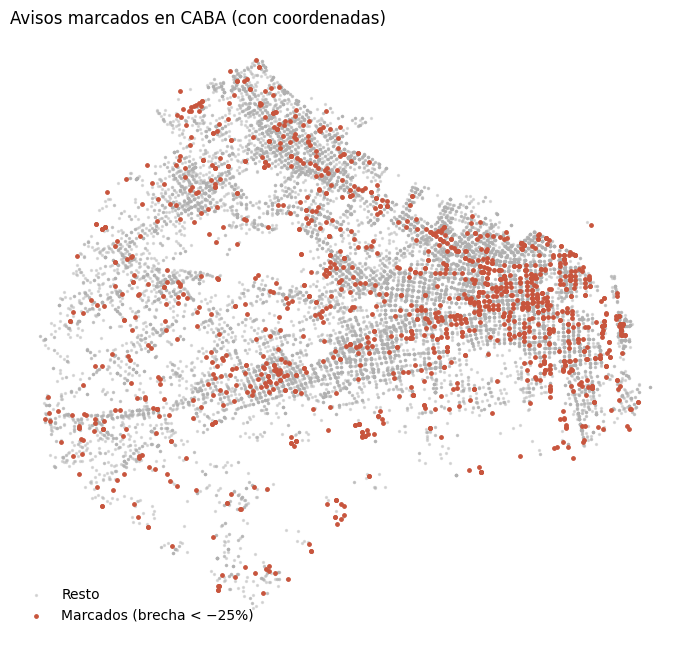

In [22]:
geo = df[df["lat"].notna()]
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(geo["lon"], geo["lat"], s=2, color=GRIS, alpha=0.4, label="Resto")
marc = geo[geo["marcado"]]
ax.scatter(marc["lon"], marc["lat"], s=6, color=ROJO, label=f"Marcados (brecha < −25%)")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="lower left", frameon=False)
ax.set_title("Avisos marcados en CABA (con coordenadas)", loc="left")
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

> **Interpretación:** Los avisos marcados no se reparten parejo: los barrios con más marcados (Parque Avellaneda, Puerto Madero, Mataderos, Barracas, más de 10% cada uno) son también los barrios donde el modelo erra más, y la correlación entre las dos cosas es alta (0,84). La correlación es en parte mecánica, porque el error del barrio se mide con las mismas brechas que deciden la marca; aun así indica que, como el umbral de −25% es el mismo para toda la ciudad, en los barrios donde el modelo es menos preciso una brecha grande es más común y puede reflejar el error del modelo más que un precio atípico. En el mapa los marcados aparecen en toda la ciudad, con más densidad en el centro y el este. Por eso la lista de esos barrios hay que leerla con más cautela.

### Control de robustez: umbral según el error de cada barrio

El umbral de −25% equivale a unas 2 veces el error típico del modelo en toda la ciudad. Como el modelo erra más en algunos barrios, se repite la marca con la misma regla pero usando el error de cada barrio: un aviso queda marcado si su brecha es menor a 2 veces el error típico de su barrio (los barrios con menos de 50 avisos usan el de la ciudad). Los avisos marcados con los dos criterios son los más confiables.

In [23]:
error_ciudad = df["brecha"].abs().median()
veces = PARAMS["umbral"] / -error_ciudad   # el umbral de la ciudad equivale a ~2 veces su error típico
error_barrio = df.groupby("barrio")["brecha"].transform(lambda s: s.abs().median())
avisos_barrio = df.groupby("barrio")["brecha"].transform("size")
error_barrio = error_barrio.where(avisos_barrio >= 50, error_ciudad)   # barrios chicos: error de la ciudad
df["marcado_barrio"] = df["brecha"] < -veces * error_barrio
print(f"El umbral de −25% equivale a {veces:.1f} veces el error típico de la ciudad ({100 * error_ciudad:.1f}%)")

El umbral de −25% equivale a 2.0 veces el error típico de la ciudad (12.7%)


In [24]:
ambos = df["marcado"] & df["marcado_barrio"]
robustez = pd.Series({
    "Marcados con el umbral de la ciudad": df["marcado"].sum(),
    "Marcados con el umbral de su barrio": df["marcado_barrio"].sum(),
    "Marcados con los dos criterios": ambos.sum(),
    "Con los dos criterios y sin señal de error de carga": (ambos & ~df["senal_error_carga"]).sum(),
}).to_frame("avisos")

barrios = df.groupby("barrio").filter(lambda g: len(g) >= 100).groupby("barrio").agg(
    error=("brecha", lambda s: s.abs().median()), ciudad=("marcado", "mean"), barrio=("marcado_barrio", "mean"))
print(f"Correlación entre % de marcados y error del barrio: con el umbral de la ciudad {barrios[['ciudad', 'error']].corr('spearman').iloc[0, 1]:.2f}, "
      f"con el umbral de su barrio {barrios[['barrio', 'error']].corr('spearman').iloc[0, 1]:.2f}")
robustez

Correlación entre % de marcados y error del barrio: con el umbral de la ciudad 0.84, con el umbral de su barrio -0.35


,avisos
Marcados con el umbral de la ciudad,1704
Marcados con el umbral de su barrio,1686
Marcados con los dos criterios,1434
Con los dos criterios y sin señal de error de carga,1225


> **Interpretación:** La marca resiste el control: 1.434 de los 1.704 avisos (84%) quedan marcados también cuando el umbral se ajusta al error de cada barrio, y la correlación entre el % de marcados y el error del barrio pasa de 0,84 a −0,35 (en parte mecánica, por el mismo motivo que en la sección 9), así que el sesgo hacia los barrios donde el modelo erra más se corrige. Los 270 avisos que se caen están sobre todo en esos barrios (como Puerto Madero), donde una brecha de −25% está dentro de lo que el modelo puede errar. Si además se descartan los que tienen señales de error de carga, quedan 1.225 avisos: esa es la lista más confiable para investigar.

## 10. Ranking de avisos a investigar

Una fila por unidad: los posibles duplicados (misma dirección y superficie) se muestran una sola vez, con la cantidad
de avisos que la repiten. Se ordena de la brecha más negativa a la menos negativa. Las columnas de señales indican qué
revisar primero.

In [25]:
df["grupo_unidad"] = modelo.grupo_de_unidad(df)
marcados = df[df["marcado"]].sort_values("brecha")
ranking = marcados.drop_duplicates("grupo_unidad").copy()
ranking["avisos_de_la_unidad"] = ranking["grupo_unidad"].map(marcados["grupo_unidad"].value_counts())
ranking["brecha_%"] = (100 * ranking["brecha"]).round(1)
ranking["precio_m2_esperado"] = ranking["precio_m2_esperado"].round(0)

columnas = ["id_aviso", "barrio", "zona", "precio_usd", "m2_final", "ambientes", "antiguedad", "precio_m2_usd",
            "precio_m2_esperado", "brecha_%", "marcado_barrio", "bajo_de_precio", "senal_error_carga", "avisos_de_la_unidad", "link"]
ranking = ranking[columnas].reset_index(drop=True)
ranking.index += 1
print(f"Avisos marcados: {len(marcados):,} | unidades distintas en el ranking: {len(ranking):,}")
ranking.drop(columns="link").head(15)

Avisos marcados: 1,704 | unidades distintas en el ranking: 1,590


,id_aviso,barrio,zona,precio_usd,m2_final,ambientes,antiguedad,precio_m2_usd,precio_m2_esperado,brecha_%,marcado_barrio,bajo_de_precio,senal_error_carga,avisos_de_la_unidad
1,MLA1998076649,paternal,paternal_1,75000.0,706.0,NaN,15.0,106.232295,1194.0,-91.1,True,False,True,1
2,MLA1937244655,floresta,floresta_3,110000.0,753.0,3.0,56.0,146.082337,983.0,-85.1,True,False,True,1
3,MLA3732462002,villa-lugano,villa-lugano,75000.0,670.0,4.0,40.0,111.940299,561.0,-80.1,True,False,True,1
4,MLA3726622514,puerto-madero,puerto-madero,123000.0,106.0,4.0,10.0,1160.377358,4963.0,-76.6,True,False,False,1
5,MLA1913807213,puerto-madero,puerto-madero,110000.0,95.0,4.0,10.0,1157.894737,4756.0,-75.7,True,False,False,1
6,MLA1961910855,puerto-madero,puerto-madero,120000.0,99.0,3.0,NaN,1212.121212,4837.0,-74.9,True,False,False,1
7,MLA3650073484,villa-general-mitre,villa-general-mitre,58000.0,135.0,5.0,50.0,429.629630,1563.0,-72.5,True,False,False,1
8,MLA1946226951,villa-soldati,villa-soldati,29000.0,96.0,5.0,61.0,302.083333,1042.0,-71.0,True,False,False,1
9,MLA2704621290,parque-chacabuco,parque-chacabuco,105000.0,215.0,4.0,NaN,488.372093,1574.0,-69.0,True,False,True,1
10,MLA2578657486,floresta,floresta_0,110000.0,200.0,8.0,30.0,550.000000,1766.0,-68.9,True,False,False,1


In [26]:
sin_senal = ranking[~ranking["senal_error_carga"]]
print(f"Unidades sin señal de error de carga: {len(sin_senal):,} ({100 * len(sin_senal) / len(ranking):.1f}%)")
sin_senal.drop(columns="link").head(10)

Unidades sin señal de error de carga: 1,364 (85.8%)


,id_aviso,barrio,zona,precio_usd,m2_final,ambientes,antiguedad,precio_m2_usd,precio_m2_esperado,brecha_%,marcado_barrio,bajo_de_precio,senal_error_carga,avisos_de_la_unidad
4,MLA3726622514,puerto-madero,puerto-madero,123000.0,106.0,4.0,10.0,1160.377358,4963.0,-76.6,True,False,False,1
5,MLA1913807213,puerto-madero,puerto-madero,110000.0,95.0,4.0,10.0,1157.894737,4756.0,-75.7,True,False,False,1
6,MLA1961910855,puerto-madero,puerto-madero,120000.0,99.0,3.0,NaN,1212.121212,4837.0,-74.9,True,False,False,1
7,MLA3650073484,villa-general-mitre,villa-general-mitre,58000.0,135.0,5.0,50.0,429.629630,1563.0,-72.5,True,False,False,1
8,MLA1946226951,villa-soldati,villa-soldati,29000.0,96.0,5.0,61.0,302.083333,1042.0,-71.0,True,False,False,1
10,MLA2578657486,floresta,floresta_0,110000.0,200.0,8.0,30.0,550.000000,1766.0,-68.9,True,False,False,1
11,MLA3655896656,barracas,barracas,79000.0,172.0,4.0,60.0,459.302326,1453.0,-68.4,True,False,False,1
13,MLA3717245774,recoleta,recoleta_4,295000.0,347.0,11.0,60.0,850.144092,2372.0,-64.2,True,False,False,1
15,MLA3567497626,monserrat,monserrat_4,155000.0,276.0,10.0,45.0,561.594203,1466.0,-61.7,True,False,False,1
17,MLA3518197798,barracas,barracas_2,65000.0,125.0,4.0,80.0,520.000000,1329.0,-60.9,True,True,False,1


In [27]:
titulos = df.set_index("id_aviso").loc[ranking["id_aviso"], "titulo"].str.lower()
for palabra in ["reciclar", "refaccionar", "renta"]:
    print(f"Avisos del ranking con \"{palabra}\" en el título: {titulos.str.contains(palabra).sum()}")

Avisos del ranking con "reciclar" en el título: 38
Avisos del ranking con "refaccionar" en el título: 23
Avisos del ranking con "renta" en el título: 16


**Revisión en el portal** (05/10/2026), para que sea trazable. La posición es la del ranking guardado en `avisos_a_investigar.csv`.

| Posición | Aviso | Barrio | Brecha | Qué se encontró |
|---|---|---|---|---|
| 1 | MLA1998076649 | Paternal | −91,1% | Monoambiente que el portal publica con "3012 m² totales": error de superficie |
| 2 | MLA1937244655 | Floresta | −85,1% | Teníamos 753 m²; el portal hoy dice 81 m²: error de superficie, ya corregido en el portal |
| 4 | MLA3726622514 | Puerto Madero | −76,6% | Aviso real y activo (bajó a USD 119.900), en el barrio Rodrigo Bueno, un barrio popular dentro de Puerto Madero |
| 6 | MLA1961910855 | Puerto Madero | −74,9% | Ya no está publicado. El título era "compro sucesiones...": no era una venta |
| 293 | MLA2746462602 | Villa Urquiza | −37,8% | Ya no está publicado |
| 325 | MLA2966523532 | Almagro | −37,1% | Publicación pausada |
| 358 | MLA1930007877 | Recoleta | −36,4% | Aviso real: faltan instalar los artefactos de cocina y baño |
| 897 | MLA3533634138 | Palermo | −29,5% | Ya no está publicado |
| 1068 | MLA1692049495 | Belgrano | −28,1% | Aviso real: se vende con inquilino hasta mayo de 2028 |

> **Interpretación:** Revisamos en el portal nueve avisos del ranking (el 05/10/2026). Los primeros puestos no son oportunidades: dos son errores de superficie (un monoambiente publicado con 3.012 m² totales y un 3 ambientes cargado con 753 m² que en el portal hoy figura con 81 m²), uno no era una venta ("compro sucesiones") y otro es real pero está en el barrio Rodrigo Bueno, un barrio popular dentro de Puerto Madero, que el modelo compara con las torres porque en ese barrio la zona de referencia es el barrio completo. En la zona intermedia de la lista (brechas de −28% a −38%, marcados con los dos criterios y sin señales de error), los avisos son reales, pero los que pudimos leer tienen un motivo concreto para el descuento que el dataset no registra: uno se vende con inquilino hasta 2028 y otro tiene la cocina y los baños sin terminar. De los demás, tres ya no estaban publicados o estaban pausados. Esto confirma que la brecha sirve para priorizar qué revisar y no como lista de oportunidades: cuanto más extrema, más probable es un error, y en los casos intermedios hay que leer el aviso antes de sacar conclusiones. En los títulos del ranking aparecen "reciclar" (38), "refaccionar" (23) y "renta" (16), que podrían sumarse como señales en una próxima versión.

In [28]:
df[["id_aviso", "zona", "precio_m2_usd", "precio_m2_esperado", "brecha", "marcado", "senal_error_carga"]].to_csv(
    PARAMS["salida_precio_esperado"], sep="\t", index=False)
ranking.to_csv(PARAMS["salida_ranking"], index_label="posicion")
print(f"Guardado: {PARAMS['salida_precio_esperado'].name} y {PARAMS['salida_ranking'].name}")

Guardado: precio_esperado.tsv y avisos_a_investigar.csv


## Ingeniería de variables

Variables derivadas que usa el análisis. Detalle de todas las columnas en `docs/entregas_grupo/diccionario_datos.md`.

| Variable | Fórmula | Unidad | Fuente de los componentes | Faltantes | Control de rango |
|---|---|---|---|---|---|
| `precio_usd` | Último monto de `precio_texto` (corrige los 627 precios concatenados) | USD | Listado de MercadoLibre | Ninguno: los avisos en pesos se excluyen | Entre USD 20.000 y USD 50.000 por m² (notebook 01) |
| `m2_final` | `m2` si está entre 15 y 1.000; si no, `superficie_total` en ese rango | m² | Listado y ficha de MercadoLibre | Si ninguna sirve, el aviso se excluye | 15 a 1.000 m² |
| `precio_m2_usd` | `precio_usd / m2_final` | USD/m² | Las dos anteriores | Ninguno | Ver tabla de abajo |
| `antiguedad` | Años declarados; un año de construcción se pasa a edad | años | Ficha de MercadoLibre | 2,8% sin dato: categoría propia en el modelo | 0 a 150 años |
| `expensas_usd` | Expensas en pesos / dólar MEP del 14/08/2026 (1.518,05) | USD por mes | Ficha de MercadoLibre y Ámbito | 16% sin dato; no se usa en el modelo | Montos en ARS mayores a 10 millones, vacío |
| `zona` | Sub-zona en los barrios donde mejora la referencia; si no, barrio | categoría | KMeans sobre `lat`/`lon` (pipeline) y error fuera de muestra (sección 2) | Avisos sin coordenadas: barrio | Zonas con al menos 10 avisos |
| `precio_m2_esperado` | exp(predicción fuera de muestra del modelo) | USD/m² | Características y zona | Ninguno | Ver tabla de abajo |
| `brecha` | `precio_m2_usd / precio_m2_esperado − 1` | proporción | Las dos anteriores | Ninguno | Ver tabla de abajo |

In [29]:
df[["precio_m2_usd", "m2_final", "antiguedad", "precio_m2_esperado", "brecha"]].describe(percentiles=[0.01, 0.5, 0.99]).T.round(2)

,count,mean,std,min,1%,50%,99%,max
precio_m2_usd,27579.0,2629.78,1290.62,106.23,888.39,2392.86,7265.26,32697.55
m2_final,27579.0,72.35,54.00,15.00,22.00,57.00,280.00,770.00
antiguedad,26808.0,35.53,23.15,0.00,1.00,40.00,93.00,146.00
precio_m2_esperado,27579.0,2518.47,947.14,561.24,1017.40,2379.10,6427.63,8975.41
brecha,27579.0,0.04,0.27,-0.91,-0.39,0.01,0.83,11.12


## Fuentes externas

Fichas completas, con fuente, cobertura, período, granularidad, mecanismo de unión, variable derivada, aporte y
limitaciones, en `docs/entregas_grupo/fuentes_externas.md`.

| Fuente | Granularidad | Variable | Aporta a | Estado |
|---|---|---|---|---|
| Normalizador de direcciones USIG (GCBA) | Punto | `lat`, `lon` | Sub-zonas y zona de referencia | Integrada |
| Estaciones de subte (BA Data) | Punto | `dist_transporte_m` | H3 (no se apoyó) | Integrada |
| Polos de centralidad (definición propia) | Punto | `dist_centralidad_m` | H3 (no se apoyó) | Integrada |
| Dólar MEP del 14/08/2026 | Un valor | `expensas_usd` | Eficiencia de expensas | Integrada |
| Ferrocarril y Metrobus (BA Data) | Punto | `dist_tren_m`, `dist_metrobus_m` | H3 en el sur y el oeste | Prevista |
| Espacios verdes (BA Data) | Polígono | `dist_espacio_verde_m` | Efecto del entorno | Prevista |
| Barrios populares (BA Data) | Polígono | `en_barrio_popular` | Modelo (caso Rodrigo Bueno, sección 10) | Prevista |
| Permisos de obra (BA Data) | Punto | `permisos_obra_500m` | Dinamismo de zona | Prevista |
| Polígonos de barrios (BA Data) | Polígono | `barrio_oficial` | Control de calidad | Prevista |

**Compatibilidad con la unidad de análisis.** Todas, salvo los polígonos de barrios, se unen a cada aviso por punto o
por un polígono más chico que la zona, así que toman valores distintos para avisos de la misma zona y pueden explicar
diferencias dentro de ella. Se descartaron las fuentes agregadas por comuna, que toman el mismo valor para barrios
distintos.

## 11. Conclusiones

### Evaluación de H1

**Estado: apoyo débil.** La brecha sirve para priorizar qué revisar, pero no prueba que haya precios atípicos más allá del error del modelo.

Hay 1.704 avisos (6,2%) que piden más de 25% menos que su precio esperado. Pero esa proporción es casi la que produciría el error del modelo por sí solo (6,0% si el error fuera normal): con estos datos no se puede distinguir, para un aviso dado, un precio atípico de un error de estimación. Lo que sí muestra el análisis es que la brecha ordena: entre los marcados hay más bajas de precio (13,3% contra 6,0%) y más señales de error de carga (14,4% contra 11,8%), y la marca se mantiene en 1.434 avisos (84%) con un umbral ajustado al error de cada barrio.

Además, un precio bajo no es una oportunidad. El 14% de los marcados tiene señales de error de carga, y la revisión en el portal mostró que los casos más extremos son errores de superficie, avisos que no eran ventas o ubicaciones especiales que el modelo no distingue (el barrio Rodrigo Bueno dentro de Puerto Madero). En la zona intermedia los avisos son reales, pero el descuento suele tener un motivo que el dataset no registra, como venderse con inquilino o estar sin terminar. En los avisos que bajaron de precio, en el caso típico la baja solo los acerca a su precio esperado, lo que se parece más a un vendedor apurado que a una ganga.

En síntesis, la brecha de precio funciona como filtro para priorizar qué avisos revisar: de 27.579 avisos deja 1.225 marcados con los dos criterios y sin señales de error. No alcanza, por sí sola, para afirmar que esos departamentos están subvaluados: confirmarlo requiere leer cada aviso y, idealmente, datos de precio de cierre y del estado del inmueble.

### Qué NO mide este análisis

- **Precio de cierre:** la brecha es contra precios publicados. Una brecha de −25% puede achicarse si el resto de la
  zona negocia más que el promedio.
- **Estado del departamento:** el aviso no informa reciclados, humedad ni defectos; un precio bajo puede reflejarlos.
- **Tiempo:** hay una sola foto (agosto de 2026). No sabemos si la brecha se sostiene o se cierra.
- **Causalidad:** las primas por característica son asociaciones dentro de la zona.

### Limitaciones del modelo

- Error típico de ~13% por aviso: sirve para ordenar avisos, no para tasar uno en particular, ni para separar un precio atípico de un error de estimación.
- La marca de outliers y la elección de los barrios donde se usa la sub-zona se calcularon con todos los avisos y con particiones que no agrupan por unidad: tocan la separación de la validación cruzada, con un efecto chico (pendiente).
- La zona de referencia es la sub-zona solo en los barrios donde mejora; en el resto, el barrio puede esconder
  diferencias internas.
- Los avisos sin antigüedad o sin piso tienen su propia categoría: su precio esperado es menos preciso.

## 12. Síntesis general de la PreEntrega 2

Cierre de los tres notebooks (01 limpieza, 02 EDA, 03 precio esperado).

### Principales hallazgos

- El precio por m² varía mucho entre barrios (mediana de USD 1.016 en Villa Lugano a USD 6.125 en Puerto Madero) y también dentro de cada uno: la mediana del barrio es una referencia poco precisa.
- La antigüedad es lo que más explica el precio dentro de una zona: un edificio de 0 a 5 años se publica 37% más caro por m² que uno de más de 70. Varias asociaciones simples (subte, amenities) estaban mezcladas con ella.
- Un modelo de precio esperado con las características del departamento y su zona erra 12,7% en la mediana, fuera de muestra, contra 17,2% de la mediana de la zona.
- 1.704 avisos (6,2%) se publican más de 25% por debajo de su precio esperado, una proporción parecida a la que daría el error del modelo por sí solo. La brecha ordena bien (más bajas de precio y errores de carga entre los marcados), pero los casos extremos suelen ser errores de carga y los intermedios tienen motivos que el aviso no registra.

### Problemas de calidad detectados

- 627 precios concatenados por "BAJÓ DE PRECIO" (la mediana correcta es USD 130.000, no 135.000).
- 68 avisos duplicados que la deduplicación por link no detectaba, y 3.059 posibles duplicados de la misma unidad con otro ID.
- Faltantes disfrazados (`ambientes` en 0, `departamentos_por_piso` en 99), superficies y pisos mal cargados, expensas en moneda equivocada.
- Columnas "solo Sí", donde el vacío no distingue "no tiene" de "no se cargó".
- Geocodificación desigual por barrio (de 59,5% de éxito en Puerto Madero a 92,5% en Boedo).

### Decisiones de limpieza adoptadas

- Se excluyeron 343 avisos: 68 duplicados, 237 en pozo, 28 con superficie inválida, 5 en pesos, 4 con precio menor a USD 20.000 y 1 con precio imposible. Quedan registrados con su motivo.
- Se corrigieron los precios concatenados y se convirtieron las expensas con el dólar MEP del 14/08/2026.
- Los posibles duplicados, los outliers de precio por m² y las incoherencias se marcaron, no se borraron.

### Hipótesis

| Hipótesis | Estado |
|---|---|
| H1: hay avisos claramente por debajo del precio esperado | Apoyo débil: la brecha prioriza qué revisar, pero no prueba precios atípicos más allá del error del modelo |
| H2: la sub-zona es mejor referencia que el barrio | Apoyo parcial: mejora en 28 de los 41 barrios con más de una sub-zona; el modelo la usa solo ahí |
| H3: la ubicación (subte, centralidad) explica diferencias dentro del barrio | No se apoya, una vez controlada la antigüedad |

**Todavía no se pueden evaluar:** si la brecha se sostiene o se cierra en el tiempo (P4), el tiempo de venta, el precio de cierre y la rentabilidad por alquiler. Requieren un segundo relevamiento o datos que el portal no publica.

### Limitaciones del dataset

Precios publicados y no de cierre; una sola foto; características declaradas y no verificadas; sin información del estado del departamento; 17,9% de avisos sin coordenadas; cuatro barrios truncados por el tope de paginación.

### Próximos pasos

1. Sumar la tasa de completitud de cada aviso como filtro del ranking.
2. Marcar en el título y la descripción palabras que explican un descuento ("reciclar", "refaccionar", "renta").
3. Integrar barrios populares, tren y Metrobus, y volver a evaluar H3 en el sur y el oeste.
4. Estimar primas por grupos de barrios o por segmento de precio (pregunta G2).
5. Calcular la marca de outliers y la elección de zonas dentro de cada vuelta de la validación, y corregir los errores residuales de la limpieza (baños en 0, pisos cargados como número de unidad).
6. Repetir el scraping para validar si los avisos marcados se venden o bajan de precio antes que sus comparables (P4).
